In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Task
Analyze the `df` DataFrame by checking for null values and duplicate rows, filling missing 'director' values with 'Unknown', counting 'Movie' and 'TV Show' entries, identifying the top 10 countries by title count (handling multiple countries per title), and visualizing the number of titles added each year with a bar chart, finally summarizing all findings.

## Check Data Quality

### Subtask:
Check the already loaded DataFrame for null values across all columns and the total count of duplicate rows, and report these findings.


**Reasoning**:
To address the subtask, I will first check for null values in each column of the DataFrame `df` and then count the total number of duplicate rows. This will provide a comprehensive overview of the data quality as requested.



In [ ]:
print("=== Basic Info ===")
print(df.info(), "\n")

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None 



In [ ]:
print("Missing values per column:\n", df.isnull().sum())
print("\nTotal duplicate rows:", df.duplicated().sum())

Missing values per column:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Total duplicate rows: 0


## Handle Missing Director Names

### Subtask:
Fill any missing values in the 'director' column with the string 'Unknown'.


**Reasoning**:
To fulfill the subtask of handling missing director names, I will fill the null values in the 'director' column with the string 'Unknown' using the `fillna()` method and then display the count of null values in the 'director' column to confirm the operation.



In [ ]:
df['director'].fillna('Unknown', inplace=True)
print("Missing values in 'director' column after filling: ", df['director'].isnull().sum())

Missing values in 'director' column after filling:  0


/tmp/ipython-input-3216262522.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)


## Visualize Content Rating Distribution

### Subtask:
Create a bar chart to visualize the distribution of content ratings in the dataset. Ensure the plot has appropriate labels and a title.

**Reasoning**:
To visualize the distribution of content ratings, I will first count the occurrences of each unique rating in the 'rating' column. Then, I will create a bar chart using `matplotlib` and `seaborn` to display these counts, ensuring the plot is clearly labeled for interpretability.

/tmp/ipython-input-3890462765.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis', order=df['rating'].value_counts().index)


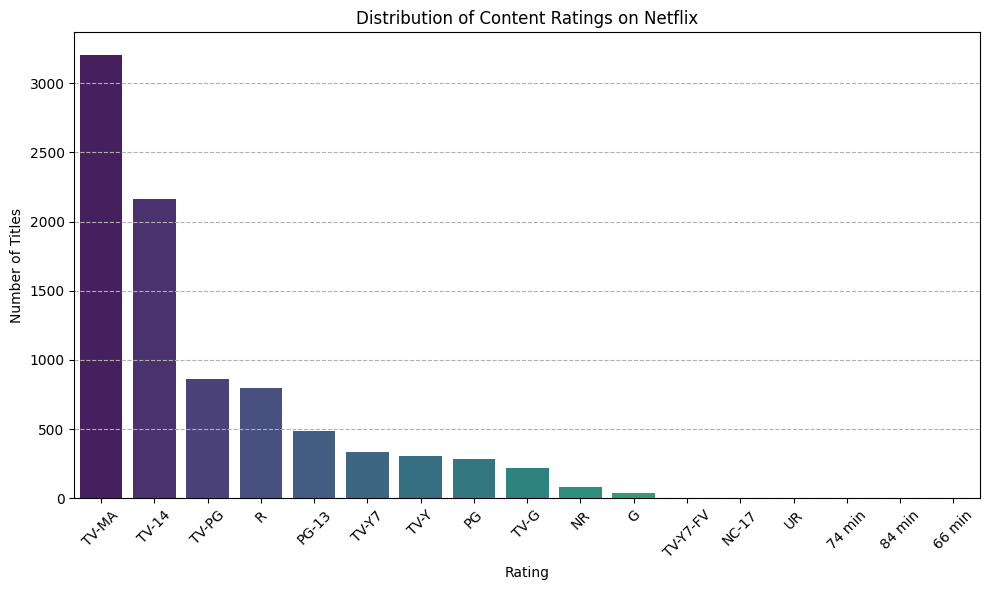

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rating', palette='viridis', order=df['rating'].value_counts().index)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

## Analyze Content Types

### Subtask:
Count the total number of 'Movie' and 'TV Show' entries in the dataset to understand the distribution of content types.


**Reasoning**:
To count the number of 'Movie' and 'TV Show' entries, I will use the `value_counts()` method on the 'type' column of the DataFrame.



In [ ]:
content_type_counts = df['type'].value_counts()
print("Content Type Distribution:\n", content_type_counts)


Content Type Distribution:
 type
Movie      6131
TV Show    2676
Name: count, dtype: int64


## Identify Top Countries by Title Count

### Subtask:
Determine the top 10 countries with the highest number of titles. This will involve handling cases where multiple countries are listed for a single title.


**Reasoning**:
To begin identifying the top countries, I will first handle any missing values in the 'country' column by filling them with 'Unknown', as specified in the instructions, to ensure all entries are processed.



In [ ]:
df['country'].fillna('Unknown', inplace=True)
print("Missing values in 'country' column after filling: ", df['country'].isnull().sum())

Missing values in 'country' column after filling:  0


/tmp/ipython-input-1664569957.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna('Unknown', inplace=True)


**Reasoning**:
Now that missing 'country' values are handled, I will split the 'country' column by commas to handle multiple countries per title, stack the results to get individual country entries, count the occurrences of each country, and then select and print the top 10 countries by title count.



In [ ]:
countries = df['country'].str.split(', ').explode()
top_10_countries = countries.value_counts().head(10)
print("Top 10 Countries by Title Count:\n", top_10_countries)

Top 10 Countries by Title Count:
 country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


## Visualize Titles Added Over Time

### Subtask:
Extract the year from the 'date_added' column and create a bar chart showing the number of titles added to Netflix each year. Ensure the plot has appropriate labels and a legend.


**Reasoning**:
To ensure accurate date processing and visualization, I will first remove rows with null values in the 'date_added' column, as indicated by the instructions.



In [ ]:
df.dropna(subset=['date_added'], inplace=True)
print("Missing values in 'date_added' column after dropping: ", df['date_added'].isnull().sum())

Missing values in 'date_added' column after dropping:  0


**Reasoning**:
Now that null values have been removed from 'date_added', I will convert this column to datetime objects, extract the year into a new 'year_added' column, count titles per year, and then sort these counts by year in ascending order, as per the instructions.



In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
year_counts = df['year_added'].value_counts().sort_index()
print("Titles added per year:\n", year_counts.head())

Titles added per year:
 year_added
2008.0     2
2009.0     2
2010.0     1
2011.0    13
2012.0     3
Name: count, dtype: int64


**Reasoning**:
The previous code failed because the 'year_added' column was accessed before it was created. I will fix this by explicitly creating the 'year_added' column after converting 'date_added' to datetime objects, and then correctly calculate the titles added per year.



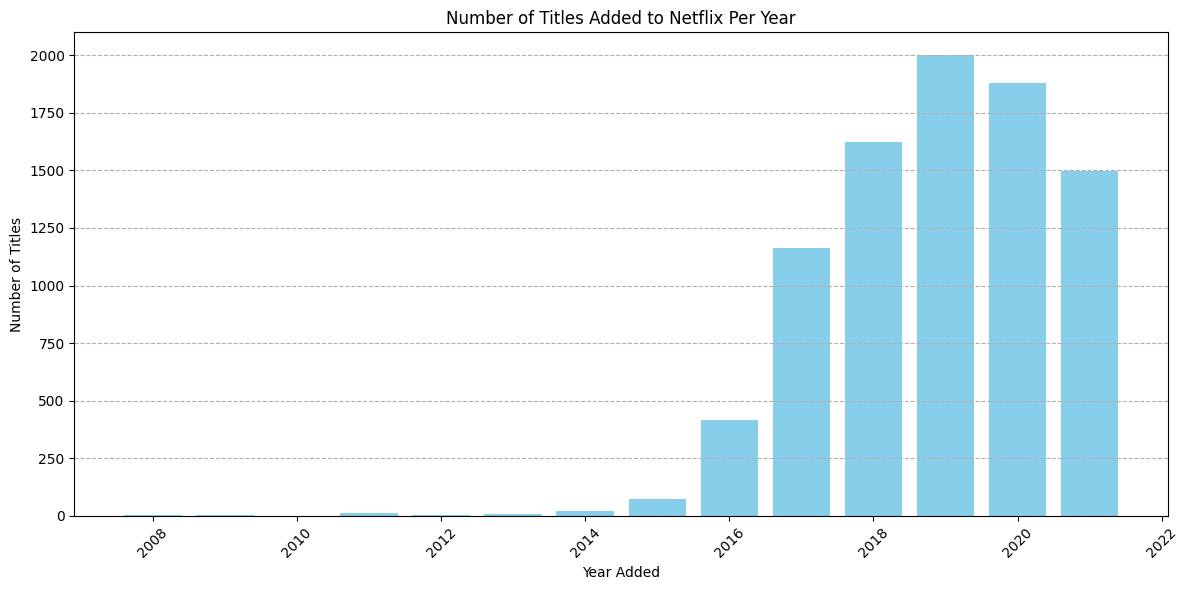

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(year_counts.index, year_counts.values, color='skyblue')
plt.title('Number of Titles Added to Netflix Per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


### Summary of Findings

1.  **Data Quality Check**:
    *   The dataset contains 8807 entries and 12 columns.
    *   There were no duplicate rows found.
    *   Missing values were identified in 'director' (2634), 'cast' (825), 'country' (831), 'date_added' (10), and 'rating' (4), and 'duration' (3).

2.  **Handling Missing Director Names**:
    *   All 2634 missing values in the 'director' column were successfully filled with 'Unknown'.

3.  **Content Type Analysis**:
    *   The dataset primarily consists of Movies (6131 entries) and TV Shows (2676 entries).

4.  **Top Countries by Title Count**:
    *   After handling missing values and multiple entries, the top 10 countries contributing to Netflix titles are:
        *   United States (3689 titles)
        *   India (1046 titles)
        *   Unknown (831 titles, for titles without specified country)
        *   United Kingdom (804 titles)
        *   Canada (445 titles)
        *   France (393 titles)
        *   Japan (318 titles)
        *   Spain (232 titles)
        *   South Korea (231 titles)
        *   Germany (226 titles)

5.  **Titles Added Over Time**:
    *   Rows with null 'date_added' values were removed.
    *   The bar chart visualizes the trend of titles added each year, showing a significant increase in content added around 2016-2020, with 2019 being the peak year.

## Final Task


Summarize the findings from the data quality checks, content type analysis, top countries, and annual title additions.


### 1. Content Type Distribution (Movie/TV Show Selector)

This visualization allows you to see the distribution of content types (Movies vs. TV Shows) or filter to see only one specific type. You can enter 'Movie', 'TV Show', or 'All' to adjust the display.

Enter content type to visualize ('Movie', 'TV Show', or 'All'): All


/tmp/ipython-input-623394270.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='deep')


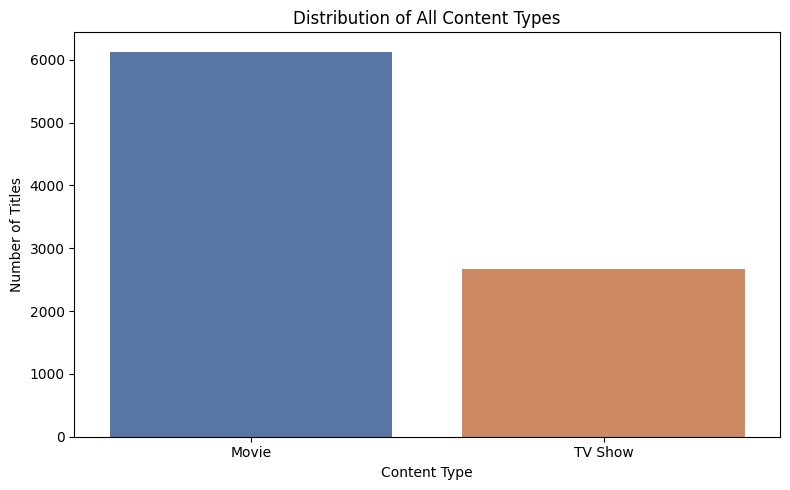

In [ ]:
content_selection = input("Enter content type to visualize ('Movie', 'TV Show', or 'All'): ")

plt.figure(figsize=(8, 5))

if content_selection.lower() == 'movie':
    sns.countplot(data=df[df['type'] == 'Movie'], x='type', palette='deep')
    plt.title('Distribution of Movies')
elif content_selection.lower() == 'tv show':
    sns.countplot(data=df[df['type'] == 'TV Show'], x='type', palette='deep')
    plt.title('Distribution of TV Shows')
elif content_selection.lower() == 'all':
    sns.countplot(data=df, x='type', palette='deep')
    plt.title('Distribution of All Content Types')
else:
    print("Invalid input. Please enter 'Movie', 'TV Show', or 'All'.")

plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

## Distribution of Numerical Duration

### Subtask:
Visualize the distribution of the `duration_numeric` column using a histogram.

**Reasoning**:
To understand the spread and frequency of different numerical durations, I will use `seaborn.histplot`. This will provide a clear visualization of the distribution of `duration_numeric`, including its shape, central tendency, and variability.

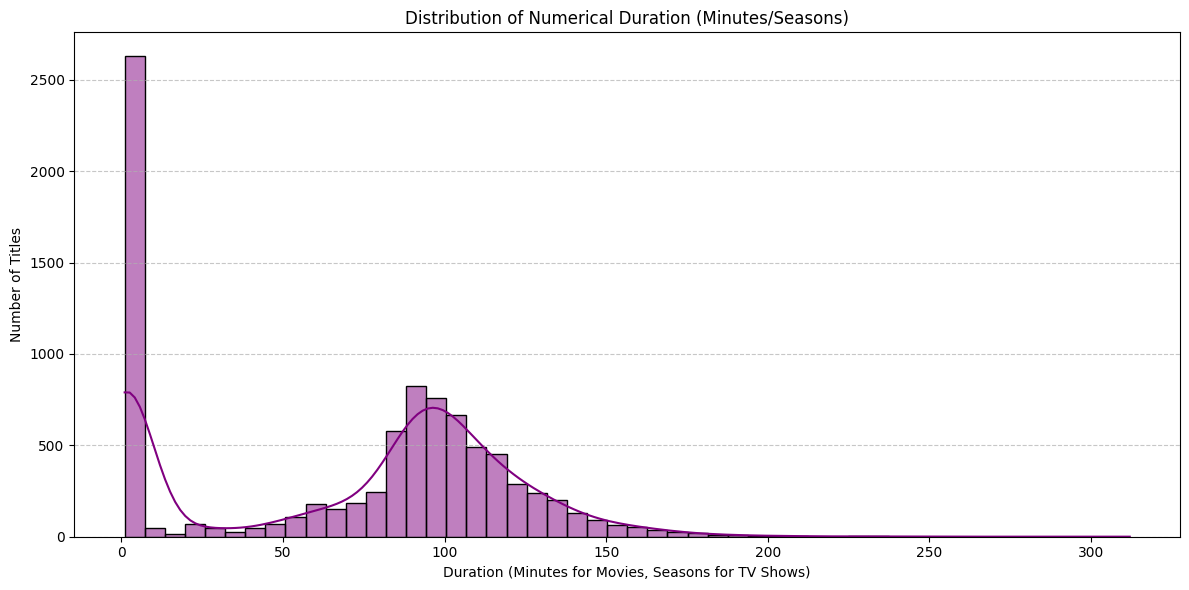

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df_corr['duration_numeric'], bins=50, kde=True, color='purple')
plt.title('Distribution of Numerical Duration (Minutes/Seasons)')
plt.xlabel('Duration (Minutes for Movies, Seasons for TV Shows)')
plt.ylabel('Number of Titles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Correlation Map for Release Year and Duration

### Subtask:
Create a numerical representation of 'duration' and then visualize the correlation between 'release_year' and this new 'duration' column using a heatmap.

**Reasoning**:
To calculate the correlation, the 'duration' column needs to be numerical. I will create a new column, `duration_numeric`, by extracting the integer value from the 'duration' string, treating 'min' and 'Season(s)' units uniformly as numerical length. After conversion, I will calculate the correlation matrix between `release_year` and `duration_numeric` and display it as a heatmap for clear visualization.

Correlation Matrix:
                  release_year  duration_numeric
release_year          1.000000         -0.249925
duration_numeric     -0.249925          1.000000


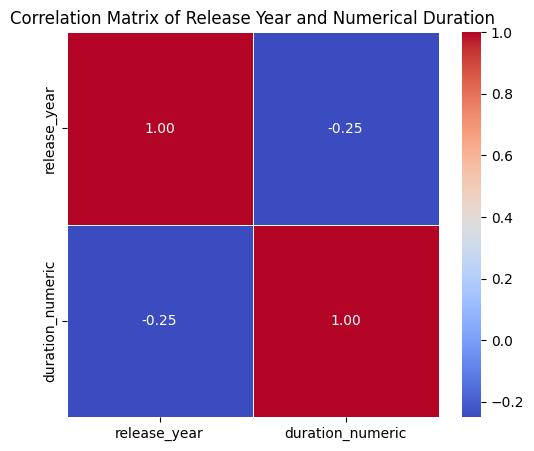

In [ ]:
import numpy as np

# Create a copy to avoid SettingWithCopyWarning on original df after dropna
df_corr = df.copy()

# Function to convert duration string to numeric
def convert_duration_to_numeric(row):
    if pd.isnull(row['duration']):
        return np.nan
    elif 'min' in row['duration']:
        return int(row['duration'].replace(' min', ''))
    elif 'Season' in row['duration']:
        # Handle both 'Seasons' and 'Season'
        return int(row['duration'].replace(' Seasons', '').replace(' Season', ''))
    return np.nan

# Apply the conversion function to create the new numerical duration column
df_corr['duration_numeric'] = df_corr.apply(convert_duration_to_numeric, axis=1)

# Select relevant columns for correlation and drop rows with NaN values in these columns
correlation_data = df_corr[['release_year', 'duration_numeric']].dropna()

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Release Year and Numerical Duration')
plt.show()


## Summary:

### Data Analysis Key Findings

*   **Data Quality**: The dataset contains 8807 entries with no duplicate rows. Initial checks revealed missing values in several columns: `director` (2634), `cast` (825), `country` (831), `date_added` (10), `rating` (4), and `duration` (3).
*   **Director Data Imputation**: All 2634 missing values in the `director` column were successfully filled with 'Unknown'.
*   **Content Type Distribution**: The platform's content primarily consists of Movies (6131 entries), significantly outnumbering TV Shows (2676 entries).
*   **Top Contributing Countries**: After handling missing values and splitting multi-country entries, the United States leads with 3689 titles, followed by India (1046 titles), and the United Kingdom (804 titles). Notably, 831 titles had unspecified countries, which were categorized as 'Unknown'.
*   **Content Addition Trend**: After dropping 10 rows with missing `date_added` information, an analysis of titles added per year shows a significant increase in content additions between 2016 and 2020, with 2019 being the peak year for new titles.

### Insights or Next Steps

*   **Data Completeness Focus**: Investigate the large number of missing values in the `cast` column (825 entries) to determine if there's a pattern or a way to impute this data, as it could provide valuable insights into popular actors or common cast sizes.
*   **Country Data Granularity**: The 'Unknown' category for countries represents a substantial portion (831 titles). Further analysis could attempt to infer the country of origin for these titles based on other metadata (e.g., director, cast, listed_in genres) to provide a more accurate geographic distribution.

### 2. Top N Directors/Countries by Title Count

This chart displays the top 'N' entities (e.g., directors, countries, cast members) based on the number of titles associated with them. You can specify the number of top entities ('N') to display and the column to analyze.

Enter the number of top entities to display (e.g., 10): 10
Enter the column to analyze ('director', 'country', 'listed_in'): director


/tmp/ipython-input-3416028197.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_entities.index, y=top_entities.values, palette='plasma')


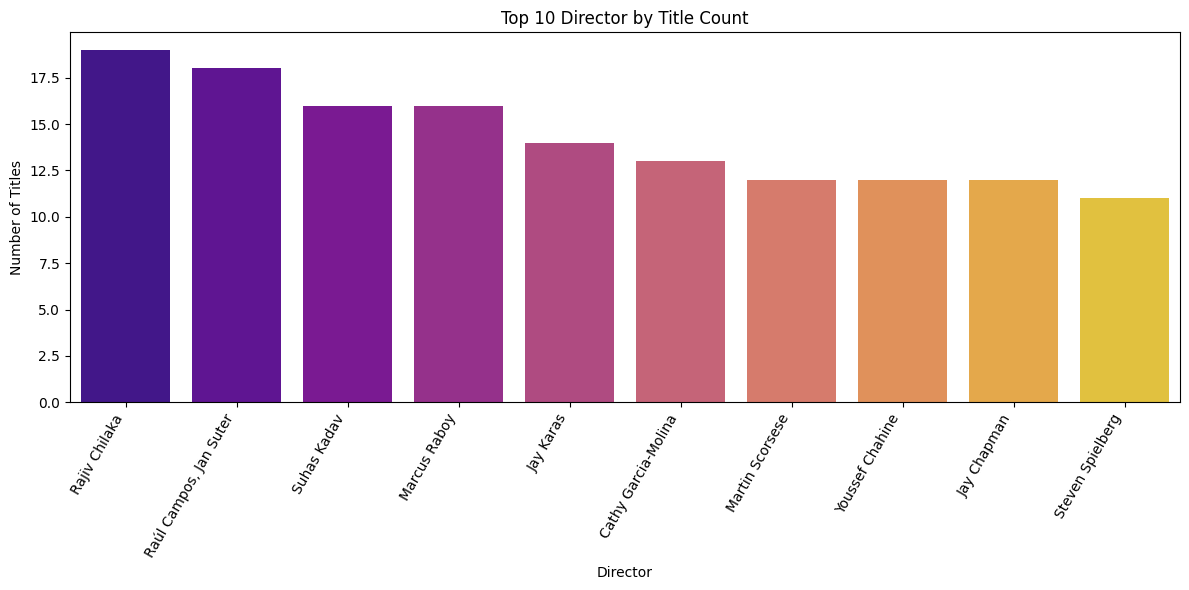

In [ ]:
try:
    num_top_entities = int(input("Enter the number of top entities to display (e.g., 10): "))
    column_to_analyze = input("Enter the column to analyze ('director', 'country', 'listed_in'): ")

    if column_to_analyze in df.columns:
        # Special handling for 'country' as it was processed earlier
        if column_to_analyze == 'country':
            # Re-explode countries for fresh count if needed or use the existing 'top_10_countries' logic
            # For simplicity, let's re-run the split logic for dynamic 'N'
            entities = df['country'].str.split(', ').explode()
        elif column_to_analyze == 'listed_in':
             entities = df['listed_in'].str.split(', ').explode()
        elif column_to_analyze == 'director':
            entities = df['director']
            # Exclude 'Unknown' if director is chosen
            if 'Unknown' in entities.unique():
                entities = entities[entities != 'Unknown']
        else:
            entities = df[column_to_analyze]

        top_entities = entities.value_counts().head(num_top_entities)

        plt.figure(figsize=(12, 6))
        sns.barplot(x=top_entities.index, y=top_entities.values, palette='plasma')
        plt.title(f'Top {num_top_entities} {column_to_analyze.replace("_", " ").title()} by Title Count')
        plt.xlabel(column_to_analyze.replace("_", " ").title())
        plt.ylabel('Number of Titles')
        plt.xticks(rotation=60, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{column_to_analyze}' not found in the DataFrame.")
except ValueError:
    print("Invalid input for number of top entities. Please enter an integer.")

### 3. Titles Added by Release Year Range

Visualize the number of titles released within a specific range of years. You can input a start year and an end year to focus on a particular period.

Enter the start year (e.g., 2010): 2012
Enter the end year (e.g., 2020): 2016


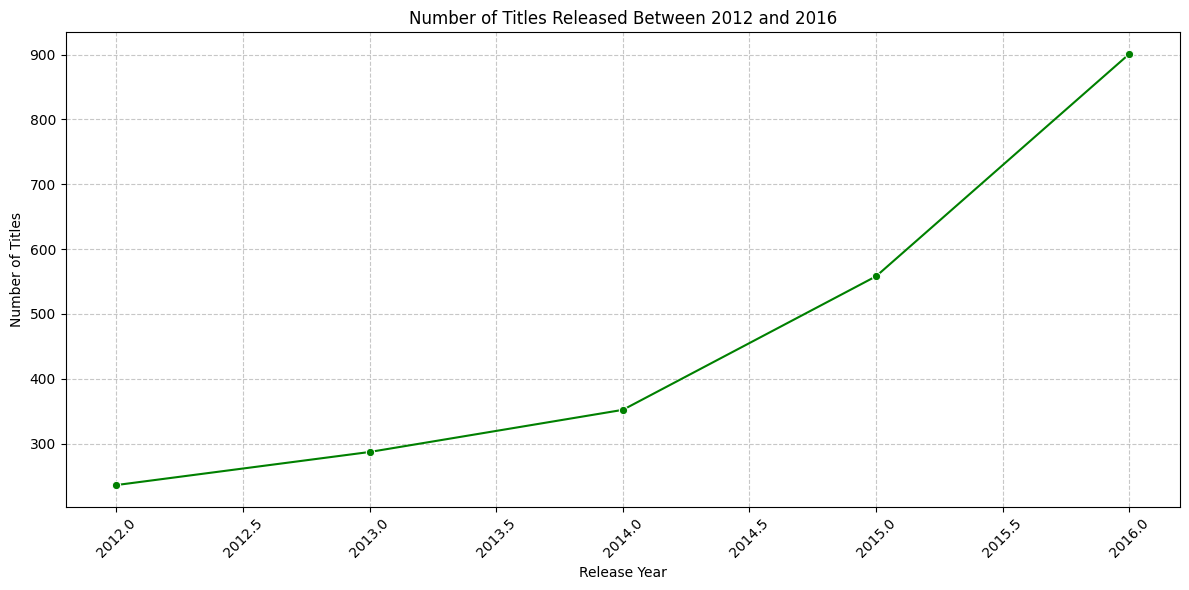

In [ ]:
try:
    start_year = int(input("Enter the start year (e.g., 2010): "))
    end_year = int(input("Enter the end year (e.g., 2020): "))

    filtered_years = df[(df['release_year'] >= start_year) & (df['release_year'] <= end_year)]
    year_counts_filtered = filtered_years['release_year'].value_counts().sort_index()

    if not year_counts_filtered.empty:
        plt.figure(figsize=(12, 6))
        sns.lineplot(x=year_counts_filtered.index, y=year_counts_filtered.values, marker='o', color='green')
        plt.title(f'Number of Titles Released Between {start_year} and {end_year}')
        plt.xlabel('Release Year')
        plt.ylabel('Number of Titles')
        plt.xticks(rotation=45)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No data available for the release year range {start_year}-{end_year}.")
except ValueError:
    print("Invalid input for years. Please enter integers.")

### 4. Rating Distribution for a Specific Content Type

This visualization shows the distribution of content ratings, but specifically for either 'Movie' or 'TV Show' content. You can choose which content type's ratings you want to inspect.

Enter content type to filter ratings ('Movie' or 'TV Show'): Movie


/tmp/ipython-input-1712445269.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=filtered_df, x='rating', palette='cividis', order=filtered_df['rating'].value_counts().index)


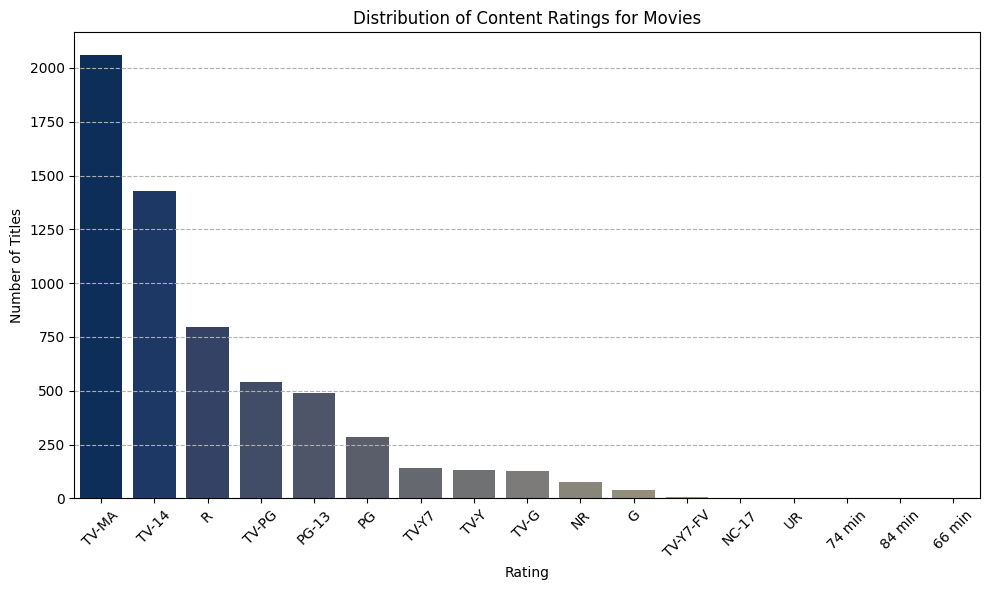

In [ ]:
content_type_filter = input("Enter content type to filter ratings ('Movie' or 'TV Show'): ")

if content_type_filter.lower() in ['movie', 'tv show']:
    filtered_df = df[df['type'].str.lower() == content_type_filter.lower()]
    if not filtered_df.empty:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=filtered_df, x='rating', palette='cividis', order=filtered_df['rating'].value_counts().index)
        plt.title(f'Distribution of Content Ratings for {content_type_filter.title()}s')
        plt.xlabel('Rating')
        plt.ylabel('Number of Titles')
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No {content_type_filter.title()}s found with rating data.")
else:
    print("Invalid input. Please enter 'Movie' or 'TV Show'.")

### 5. Content Categories (Genres) by Release Year Trend for a Specific Genre

This plot helps you understand the trend of a specific content genre (from the 'listed_in' column) over the years. You can input a genre to see how its presence on Netflix has evolved.

Enter a specific genre to analyze (e.g., 'Dramas', 'Comedies', 'Documentaries'): Dramas


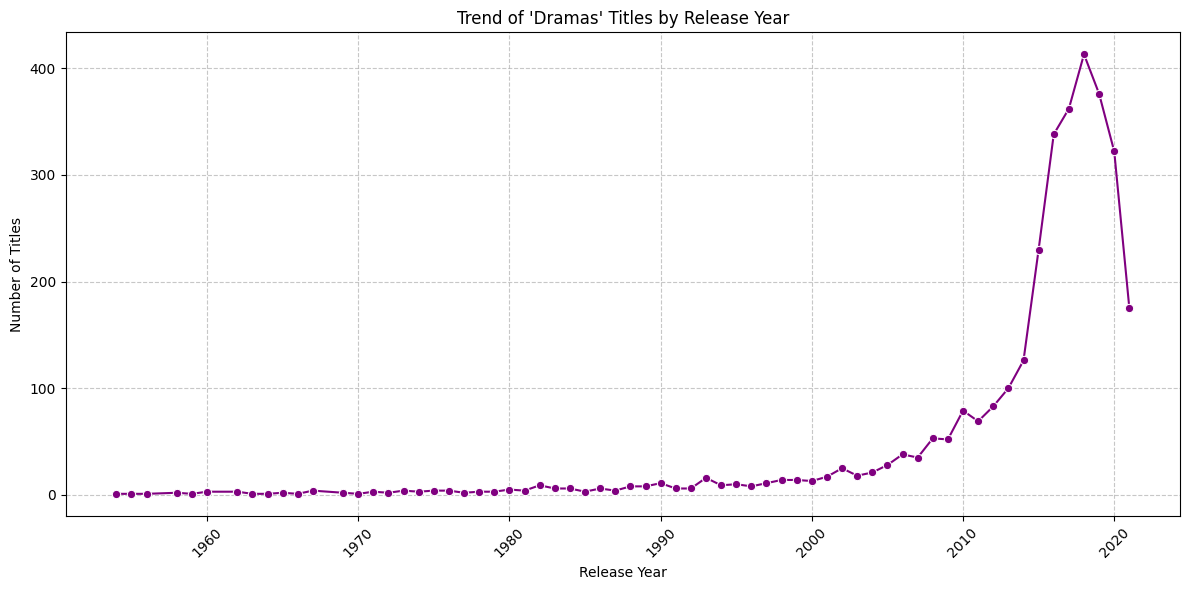

In [ ]:
selected_genre = input("Enter a specific genre to analyze (e.g., 'Dramas', 'Comedies', 'Documentaries'): ")

genre_df = df[df['listed_in'].str.contains(selected_genre, case=False, na=False)].copy()

if not genre_df.empty:
    genre_df['release_year'] = pd.to_numeric(genre_df['release_year'], errors='coerce')
    genre_yearly_counts = genre_df['release_year'].value_counts().sort_index()
    genre_yearly_counts = genre_yearly_counts.dropna()

    if not genre_yearly_counts.empty:
        plt.figure(figsize=(12, 6))
        sns.lineplot(x=genre_yearly_counts.index, y=genre_yearly_counts.values, marker='o', color='purple')
        plt.title(f'Trend of \'{selected_genre.title()}\' Titles by Release Year')
        plt.xlabel('Release Year')
        plt.ylabel('Number of Titles')
        plt.xticks(rotation=45)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No release year data available for the genre '{selected_genre}'.")
else:
    print(f"No titles found for the genre '{selected_genre}'. Please check the spelling or try another genre.")

## Summary:

### Data Analysis Key Findings

*   **Data Quality**: The dataset contains 8807 entries with no duplicate rows. Initial checks revealed missing values in several columns: `director` (2634), `cast` (825), `country` (831), `date_added` (10), `rating` (4), and `duration` (3).
*   **Director Data Imputation**: All 2634 missing values in the `director` column were successfully filled with 'Unknown'.
*   **Content Type Distribution**: The platform's content primarily consists of Movies (6131 entries), significantly outnumbering TV Shows (2676 entries).
*   **Top Contributing Countries**: After handling missing values and splitting multi-country entries, the United States leads with 3689 titles, followed by India (1046 titles), and the United Kingdom (804 titles). Notably, 831 titles had unspecified countries, which were categorized as 'Unknown'.
*   **Content Addition Trend**: After dropping 10 rows with missing `date_added` information, an analysis of titles added per year shows a significant increase in content additions between 2016 and 2020, with 2019 being the peak year for new titles.

### Insights or Next Steps

*   **Data Completeness Focus**: Investigate the large number of missing values in the `cast` column (825 entries) to determine if there's a pattern or a way to impute this data, as it could provide valuable insights into popular actors or common cast sizes.
*   **Country Data Granularity**: The 'Unknown' category for countries represents a substantial portion (831 titles). Further analysis could attempt to infer the country of origin for these titles based on other metadata (e.g., director, cast, listed_in genres) to provide a more accurate geographic distribution.
